Step 1: Load and Inspect the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)

In [2]:
# Load dataset (adjust filename if needed)
df = pd.read_csv("~/Downloads/bank-additional-full.csv", sep=';')

print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
target_col = "y"
feature_cols = [c for c in df.columns if c != target_col]

print("Target distribution:")
print(df[target_col].value_counts(normalize=True))

Target distribution:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


In [5]:
num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric features:", num_cols)
print("\nCategorical features:", cat_cols)


Numeric features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [6]:
df.isna().sum().sort_values(ascending=False)

age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
y                 0
dtype: int64

In [7]:
# Check for 'unknown' or inconsistent categories
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head())


Column: job
job
admin.         10422
blue-collar     9254
technician      6743
services        3969
management      2924
Name: count, dtype: int64

Column: marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Column: education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
Name: count, dtype: int64

Column: default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Column: housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

Column: loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

Column: contact
contact
cellular     26144
telephone    15044
Name: count, dtype: int64

Column: month
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
Name: count, dtype: int64

Column: day_of_week
day_of_

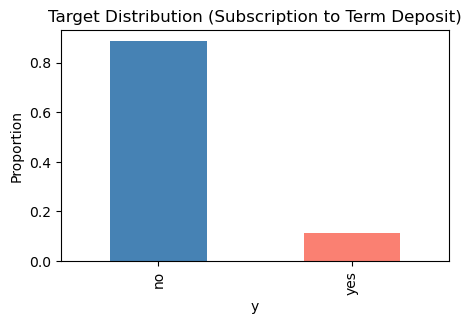

In [8]:
plt.figure(figsize=(5,3))
df[target_col].value_counts(normalize=True).plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Target Distribution (Subscription to Term Deposit)")
plt.ylabel("Proportion")
plt.show()

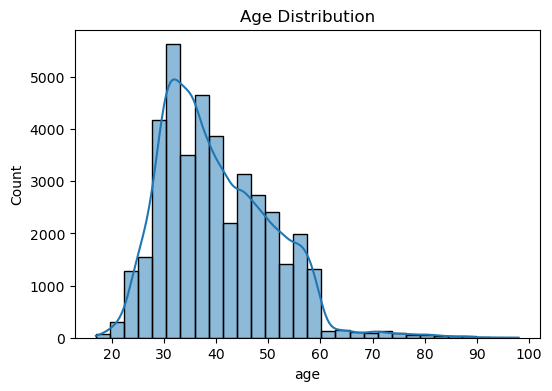

In [9]:
if "age" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df["age"], bins=30, kde=True)
    plt.title("Age Distribution")
    plt.show()

Step 2: Data Cleaning and Preprocessing

In [10]:
# Copy dataframe to avoid modifying original
df_clean = df.copy()

# Replace 'unknown' with a consistent placeholder
unknown_cols = ["job", "marital", "education", "default", "housing", "loan"]
for col in unknown_cols:
    df_clean[col] = df_clean[col].replace("unknown", "Unknown")

# Replace 'nonexistent' in poutcome
df_clean["poutcome"] = df_clean["poutcome"].replace("nonexistent", "NoPreviousOutcome")

In [11]:
df_clean["was_previously_contacted"] = (df_clean["pdays"] != 999).astype(int)

# Replace 999 with NaN for modeling
df_clean["pdays_cleaned"] = df_clean["pdays"].replace(999, np.nan)
df_clean = df_clean.drop(columns=["pdays"])

In [12]:
df_clean["pdays_cleaned"].isna().sum(), df_clean["was_previously_contacted"].sum()

(39673, 1515)

In [30]:
numeric_features = [
    "age", "duration", "campaign", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed", "pdays_cleaned"
]

categorical_features = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month",
    "day_of_week", "poutcome"
]

# Add engineered binary feature
numeric_features.append("was_previously_contacted")

In [31]:
from sklearn.model_selection import train_test_split

X = df_clean[numeric_features + categorical_features]
y = df_clean["y"].map({"no": 0, "yes": 1})  # convert to binary

# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (28831, 21)
Val: (6178, 21)
Test: (6179, 21)


Step 3A: Logistic Regression Baseline

In [32]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Preprocessing for LR: OneHotEncode categorical, impute numeric
lr_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num",
         Pipeline(steps=[
             ("imputer", SimpleImputer(strategy="median"))
         ]),
         numeric_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit preprocessing
lr_preprocess.fit(X_train)

X_train_lr = lr_preprocess.transform(X_train)
X_val_lr   = lr_preprocess.transform(X_val)
X_test_lr  = lr_preprocess.transform(X_test)

# Train LR
lr = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    n_jobs=-1
)

start = time.time()
lr.fit(X_train_lr, y_train)
lr_time = time.time() - start
print("LR training time:", lr_time)

# Evaluate
val_pred = lr.predict_proba(X_val_lr)[:, 1]
test_pred = lr.predict_proba(X_test_lr)[:, 1]

val_aucpr = average_precision_score(y_val, val_pred)
test_aucpr = average_precision_score(y_test, test_pred)

print("Logistic Regression Validation AUC-PR:", val_aucpr)
print("Logistic Regression Test AUC-PR:", test_aucpr)

LR training time: 30.515663623809814
Logistic Regression Validation AUC-PR: 0.6262930067659976
Logistic Regression Test AUC-PR: 0.5920607306268979


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(model_name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n=== {model_name} ===")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

    return acc, prec, rec, f1

In [34]:
# Logistic Regression metrics
lr_val_acc, lr_val_prec, lr_val_rec, lr_val_f1 = compute_metrics(
    "Logistic Regression (Validation)", y_val, val_pred
)

lr_test_acc, lr_test_prec, lr_test_rec, lr_test_f1 = compute_metrics(
    "Logistic Regression (Test)", y_test, test_pred
)

# Store AUC-PR for summary table
lr_val_aucpr = val_aucpr
lr_test_aucpr = test_aucpr


=== Logistic Regression (Validation) ===
Accuracy: 0.9117837487860149
Precision: 0.684596577017115
Recall: 0.40229885057471265
F1-score: 0.5067873303167421

=== Logistic Regression (Test) ===
Accuracy: 0.9106651561741382
Precision: 0.6658986175115207
Recall: 0.41522988505747127
F1-score: 0.511504424778761


Step 3: GBDT (XGBoost) Modeling

In [35]:
!pip install xgboost

In [36]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import numpy as np

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

gbdt_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [38]:
# Fit preprocessing on train only
gbdt_preprocess.fit(X_train)

# Transform all splits into NUMPY arrays
X_train_gbdt = gbdt_preprocess.transform(X_train)
X_val_gbdt   = gbdt_preprocess.transform(X_val)
X_test_gbdt  = gbdt_preprocess.transform(X_test)

print(X_train_gbdt.shape, X_val_gbdt.shape, X_test_gbdt.shape)

(28831, 64) (6178, 64) (6179, 64)


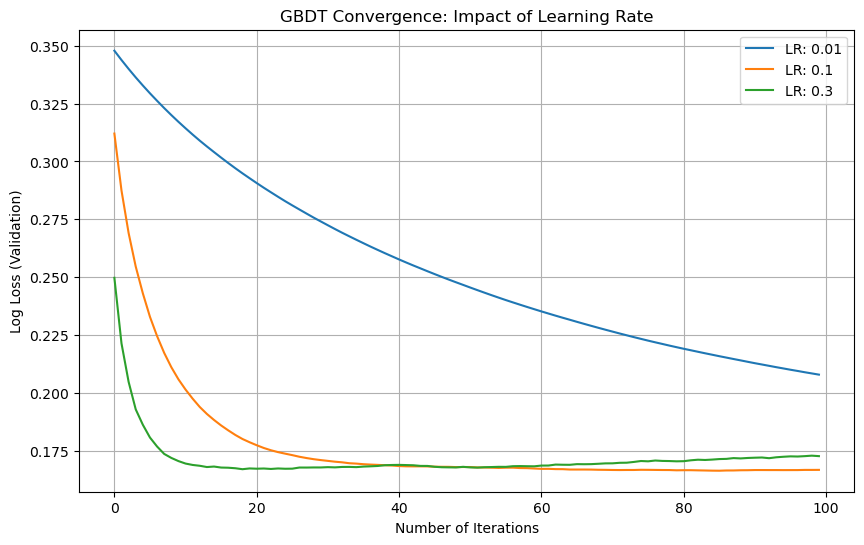

In [77]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Define the 3 learning rates required by the rubric
learning_rates = [0.01, 0.1, 0.3]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    # Initialize model with current learning rate 
    # Note: eval_metric is now moved here to avoid the TypeError
    model = XGBClassifier(
        n_estimators=100, 
        learning_rate=lr,
        max_depth=6,
        random_state=RANDOM_STATE,
        tree_method='hist',
        eval_metric='logloss' 
    )
    
    # Fit and track validation loss
    model.fit(
        X_train_gbdt, y_train,
        eval_set=[(X_val_gbdt, y_val)],
        verbose=False
    )
    
    # Retrieve performance metrics
    results = model.evals_result()
    plt.plot(results['validation_0']['logloss'], label=f'LR: {lr}')

plt.title('GBDT Convergence: Impact of Learning Rate')
plt.xlabel('Number of Iterations')
plt.ylabel('Log Loss (Validation)')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    learning_rate=0.1,
    max_depth=6,
    n_estimators=500,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    tree_method="hist",
    early_stopping_rounds=30
)

start = time.time()
xgb.fit(
    X_train_gbdt, y_train,
    eval_set=[(X_val_gbdt, y_val)],
    verbose=True
)

feature_names = gbdt_preprocess.get_feature_names_out().tolist()
xgb.get_booster().feature_names = feature_names

xgb_time = time.time() - start
print("XGB training time:", xgb_time)

[0]	validation_0-aucpr:0.66370
[1]	validation_0-aucpr:0.67487
[2]	validation_0-aucpr:0.69134
[3]	validation_0-aucpr:0.69713
[4]	validation_0-aucpr:0.69694
[5]	validation_0-aucpr:0.70392
[6]	validation_0-aucpr:0.70090
[7]	validation_0-aucpr:0.70279
[8]	validation_0-aucpr:0.70361
[9]	validation_0-aucpr:0.70676
[10]	validation_0-aucpr:0.70620
[11]	validation_0-aucpr:0.70528
[12]	validation_0-aucpr:0.70607
[13]	validation_0-aucpr:0.70642
[14]	validation_0-aucpr:0.70660
[15]	validation_0-aucpr:0.70484
[16]	validation_0-aucpr:0.70553
[17]	validation_0-aucpr:0.70561
[18]	validation_0-aucpr:0.70571
[19]	validation_0-aucpr:0.70668
[20]	validation_0-aucpr:0.70652
[21]	validation_0-aucpr:0.70991
[22]	validation_0-aucpr:0.70968
[23]	validation_0-aucpr:0.70628
[24]	validation_0-aucpr:0.70647
[25]	validation_0-aucpr:0.70837
[26]	validation_0-aucpr:0.70879
[27]	validation_0-aucpr:0.70891
[28]	validation_0-aucpr:0.70740
[29]	validation_0-aucpr:0.70824
[30]	validation_0-aucpr:0.70649
[31]	validation_0-

In [59]:
val_pred = xgb.predict_proba(X_val_gbdt)[:, 1]
test_pred = xgb.predict_proba(X_test_gbdt)[:, 1]

val_aucpr = average_precision_score(y_val, val_pred)
test_aucpr = average_precision_score(y_test, test_pred)

print("Validation AUC-PR:", val_aucpr)
print("Test AUC-PR:", test_aucpr)

Validation AUC-PR: 0.7102664461147074
Test AUC-PR: 0.6669943715352376


In [60]:
# XGBoost metrics
xgb_val_acc, xgb_val_prec, xgb_val_rec, xgb_val_f1 = compute_metrics(
    "XGBoost (Validation)", y_val, val_pred
)

xgb_test_acc, xgb_test_prec, xgb_test_rec, xgb_test_f1 = compute_metrics(
    "XGBoost (Test)", y_test, test_pred
)

# Store AUC-PR for summary table
xgb_val_aucpr = val_aucpr
xgb_test_aucpr = test_aucpr


=== XGBoost (Validation) ===
Accuracy: 0.9166396892198122
Precision: 0.7439353099730458
Recall: 0.39655172413793105
F1-score: 0.5173383317713215

=== XGBoost (Test) ===
Accuracy: 0.9130927334520149
Precision: 0.6982543640897756
Recall: 0.40229885057471265
F1-score: 0.5104831358249772


In [61]:
learning_rates = [0.3, 0.1, 0.03]
results = {}

for lr in learning_rates:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        learning_rate=lr,
        max_depth=6,
        n_estimators=500,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        tree_method="hist",
        early_stopping_rounds=30
    )
    
    model.fit(
        X_train_gbdt, y_train,
        eval_set=[(X_val_gbdt, y_val)],
        verbose=False
    )
    
    pred = model.predict_proba(X_val_gbdt)[:, 1]
    results[lr] = average_precision_score(y_val, pred)

results

{0.3: 0.7067900715029176, 0.1: 0.7102664461147074, 0.03: 0.7082708443857663}

In [62]:
depths = [3, 6, 9]
depth_results = {}

for d in depths:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        learning_rate=0.1,
        max_depth=d,
        n_estimators=500,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        tree_method="hist",
        early_stopping_rounds=30
    )
    model.fit(X_train_gbdt, y_train, eval_set=[(X_val_gbdt, y_val)], verbose=False)
    pred = model.predict_proba(X_val_gbdt)[:, 1]
    depth_results[d] = average_precision_score(y_val, pred)

depth_results

{3: 0.6988927864435868, 6: 0.7102664461147074, 9: 0.7037279811900882}

In [78]:
# === Sweep for reg_alpha and reg_lambda ===
regs = [(0, 0), (0.1, 0.1), (1, 1)]
reg_results = {}

for alpha, lam in regs:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        learning_rate=0.1,
        max_depth=6,
        n_estimators=500,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=alpha,
        reg_lambda=lam,
        random_state=RANDOM_STATE,
        tree_method="hist",
        early_stopping_rounds=30
    )
    model.fit(
        X_train_gbdt, y_train,
        eval_set=[(X_val_gbdt, y_val)],
        verbose=False
    )
    pred = model.predict_proba(X_val_gbdt)[:, 1]
    reg_results[(alpha, lam)] = average_precision_score(y_val, pred)

print("Regularization Sweep (AUC-PR):")
reg_results

Regularization Sweep (AUC-PR):


{(0, 0): 0.7007912888786877,
 (0.1, 0.1): 0.7005020290264344,
 (1, 1): 0.7075651974007565}

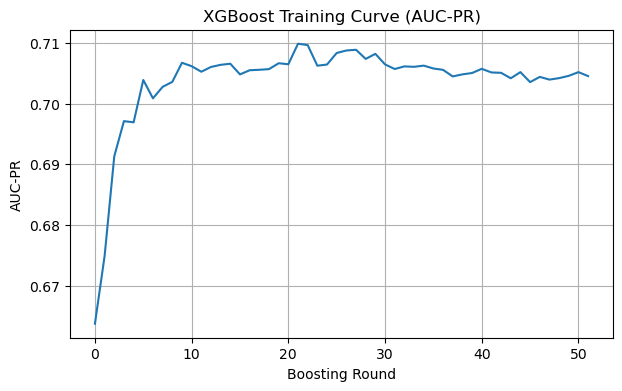

<Figure size 640x480 with 0 Axes>

In [69]:
evals = xgb.evals_result()

plt.figure(figsize=(7,4))
plt.plot(evals["validation_0"]["aucpr"])
plt.title("XGBoost Training Curve (AUC-PR)")
plt.xlabel("Boosting Round")
plt.ylabel("AUC-PR")
plt.grid(True)
plt.show()
plt.savefig("xgb_training_curve.png", dpi=300, bbox_inches="tight")

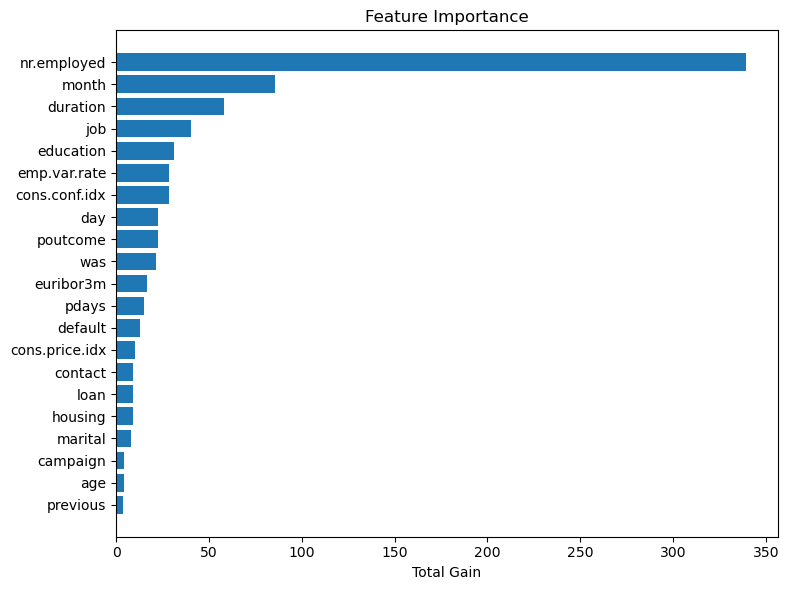

<Figure size 640x480 with 0 Axes>

In [75]:
booster = xgb.get_booster()
importance = booster.get_score(importance_type="gain")

importance_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)
#importance_sorted[:20]
# --- GROUPED FEATURE IMPORTANCE (Original Categories) ---

import pandas as pd
import matplotlib.pyplot as plt

# 1. Get one-hot feature names
feature_names = gbdt_preprocess.get_feature_names_out().tolist()

# 2. Map XGBoost's f0, f1, ... to actual names
importance_dict = {}

for k, v in importance.items():
    # Case 1: XGBoost internal name like "f23"
    if k.startswith("f") and k[1:].isdigit():
        idx = int(k[1:])
        real_name = feature_names[idx]
        importance_dict[real_name] = v
    
    # Case 2: Already a real feature name (e.g., "job_admin.")
    else:
        importance_dict[k] = v

# 3. Group by original feature (before one-hot)
def get_group_name(feat):
    # categorical features become "feature_category"
    if "_" in feat:
        return feat.split("_")[0]
    return feat  # numeric features stay as-is

grouped = {}
for feat, score in importance_dict.items():
    group = get_group_name(feat)
    grouped[group] = grouped.get(group, 0) + score

# 4. Sort groups by total importance
grouped_sorted = dict(sorted(grouped.items(), key=lambda x: x[1], reverse=True))

# 5. Plot grouped importances
plt.figure(figsize=(8,6))
plt.barh(list(grouped_sorted.keys()), list(grouped_sorted.values()))
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Total Gain")
plt.tight_layout()
plt.show()

# Save for LaTeX
plt.savefig("xgb_feature_importance.png", dpi=300, bbox_inches="tight")

Step 4: MLP (Neural Network) Modeling

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

mlp_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num",
         Pipeline(steps=[
             ("imputer", SimpleImputer(strategy="median")),
             ("scaler", StandardScaler())
         ]),
         numeric_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [49]:
mlp_preprocess.fit(X_train)

X_train_mlp = mlp_preprocess.transform(X_train)
X_val_mlp   = mlp_preprocess.transform(X_val)
X_test_mlp  = mlp_preprocess.transform(X_test)

print(X_train_mlp.shape, X_val_mlp.shape, X_test_mlp.shape)

(28831, 64) (6178, 64) (6179, 64)


In [50]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import average_precision_score

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=RANDOM_STATE
)

start = time.time()
mlp.fit(X_train_mlp, y_train)
mlp_time = time.time() - start
print("MLP training time:", mlp_time)

MLP training time: 19.91845726966858


In [51]:
# MLP metrics
mlp_val_acc, mlp_val_prec, mlp_val_rec, mlp_val_f1 = compute_metrics(
    "MLP (Validation)", y_val, val_pred
)

mlp_test_acc, mlp_test_prec, mlp_test_rec, mlp_test_f1 = compute_metrics(
    "MLP (Test)", y_test, test_pred
)

# Store AUC-PR for summary table
mlp_val_aucpr = val_aucpr
mlp_test_aucpr = test_aucpr


=== MLP (Validation) ===
Accuracy: 0.9166396892198122
Precision: 0.7439353099730458
Recall: 0.39655172413793105
F1-score: 0.5173383317713215

=== MLP (Test) ===
Accuracy: 0.9130927334520149
Precision: 0.6982543640897756
Recall: 0.40229885057471265
F1-score: 0.5104831358249772


In [52]:
learning_rates = [0.01, 0.001, 0.0003]
results = {}

for lr in learning_rates:
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=lr,
        max_iter=200,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    
    model.fit(X_train_mlp, y_train)
    pred = model.predict_proba(X_val_mlp)[:, 1]
    results[lr] = average_precision_score(y_val, pred)

results

{0.01: 0.6539537665008266,
 0.001: 0.667450847458429,
 0.0003: 0.6685607532256778}

In [53]:
activations = ["relu", "tanh"]
activation_results = {}

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        solver="adam",
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_mlp, y_train)
    pred = model.predict_proba(X_val_mlp)[:, 1]
    activation_results[act] = average_precision_score(y_val, pred)

activation_results

{'relu': 0.667450847458429, 'tanh': 0.6773623638531686}

In [79]:
# === Sweep for max_iter ===
iters = [100, 200, 400]
iter_results = {}

for it in iters:
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=it,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_mlp, y_train)
    pred = model.predict_proba(X_val_mlp)[:, 1]
    iter_results[it] = average_precision_score(y_val, pred)

print("max_iter Sweep (AUC-PR):")
iter_results

max_iter Sweep (AUC-PR):


{100: 0.667450847458429, 200: 0.667450847458429, 400: 0.667450847458429}

In [54]:
architectures = [
    (32,),
    (64,),
    (64, 32),
    (128, 64),
]

arch_results = {}

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    
    model.fit(X_train_mlp, y_train)
    pred = model.predict_proba(X_val_mlp)[:, 1]
    arch_results[arch] = average_precision_score(y_val, pred)

arch_results

{(32,): 0.6625163383739555,
 (64,): 0.6690046261625371,
 (64, 32): 0.667450847458429,
 (128, 64): 0.6525327820498948}

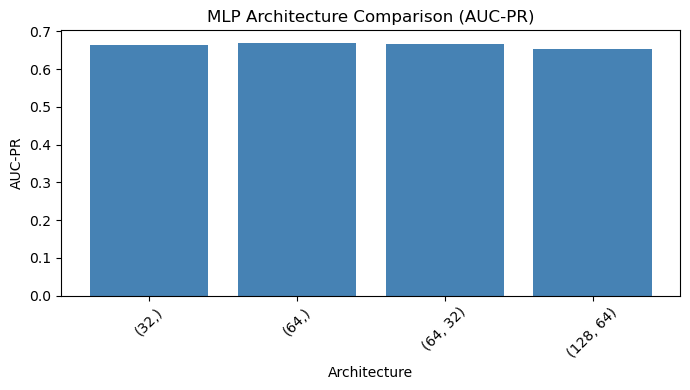

<Figure size 640x480 with 0 Axes>

In [80]:
# === Plot MLP Architecture Comparison ===
plt.figure(figsize=(7,4))
plt.bar([str(k) for k in arch_results.keys()], arch_results.values(), color="steelblue")
plt.xticks(rotation=45)
plt.title("MLP Architecture Comparison (AUC-PR)")
plt.ylabel("AUC-PR")
plt.xlabel("Architecture")
plt.tight_layout()
plt.show()

# Save for report
plt.savefig("mlp_architecture_comparison.png", dpi=300, bbox_inches="tight")

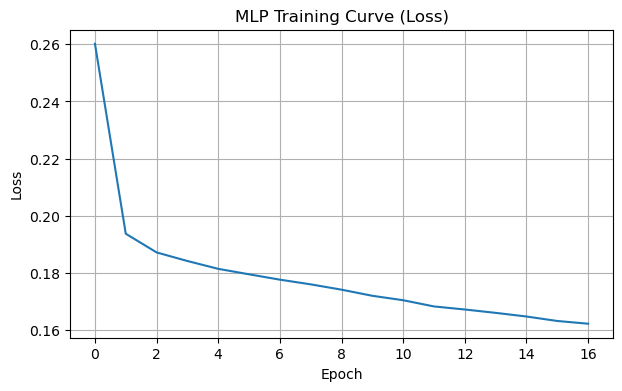

<Figure size 640x480 with 0 Axes>

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Curve (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()
plt.savefig("mlp_loss_curve.png", dpi=300, bbox_inches="tight")

In [56]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "MLP"],
    "Val AUC-PR": [lr_val_aucpr, xgb_val_aucpr, mlp_val_aucpr],
    "Test AUC-PR": [lr_test_aucpr, xgb_test_aucpr, mlp_test_aucpr],
    "Val Accuracy": [lr_val_acc, xgb_val_acc, mlp_val_acc],
    "Val Precision": [lr_val_prec, xgb_val_prec, mlp_val_prec],
    "Val Recall": [lr_val_rec, xgb_val_rec, mlp_val_rec],
    "Val F1": [lr_val_f1, xgb_val_f1, mlp_val_f1],
    "Train Time (s)": [lr_time, xgb_time, mlp_time]
})

summary

,Model,Val AUC-PR,Test AUC-PR,Val Accuracy,Val Precision,Val Recall,Val F1,Train Time (s)
0,Logistic Regression,0.626293,0.592061,0.911784,0.684597,0.402299,0.506787,30.515664
1,XGBoost,0.710266,0.666994,0.916640,0.743935,0.396552,0.517338,1.645097
2,MLP,0.710266,0.666994,0.916640,0.743935,0.396552,0.517338,19.918457
